In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/test.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

# IMPORT TRAINING_DATASET AND TEST_DATA SETS

In [3]:
train_data=pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/train.csv')
test_data=pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/test.csv')
print(train_data.shape)
print(test_data.shape)

(40000, 12)
(10000, 11)


# CHECKING DATASET STRUCTURE AND PATTERN

In [4]:
test_data.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left
0,0,Vistara,UK-816,Bangalore,Morning,zero,Afternoon,Delhi,Economy,2.67,18.0
1,1,Air_India,AI-440,Chennai,Early_Morning,zero,Morning,Delhi,Economy,NaN,5.0
2,2,SpiceJet,SG-8938,Delhi,Evening,one,Evening,Bangalore,Economy,NaN,44.0
3,3,Vistara,UK-838,Chennai,Night,one,Evening,Kolkata,Business,21.00,26.0
4,4,Air_India,AI-429,Delhi,Morning,one,Evening,Mumbai,Business,7.25,22.0


In [5]:
train_data.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584


<Axes: >

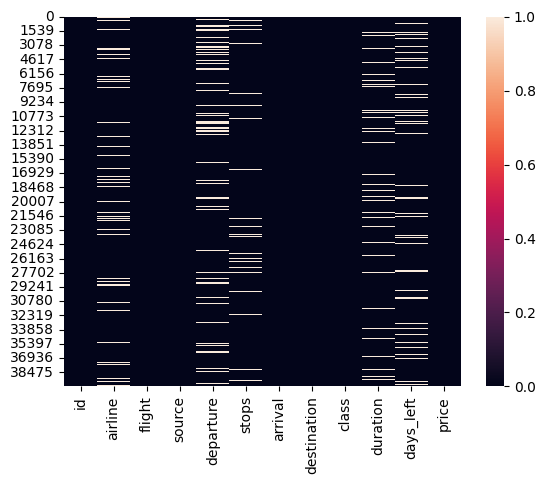

In [6]:
import seaborn as sns
sns.heatmap(train_data.isna())

<Axes: >

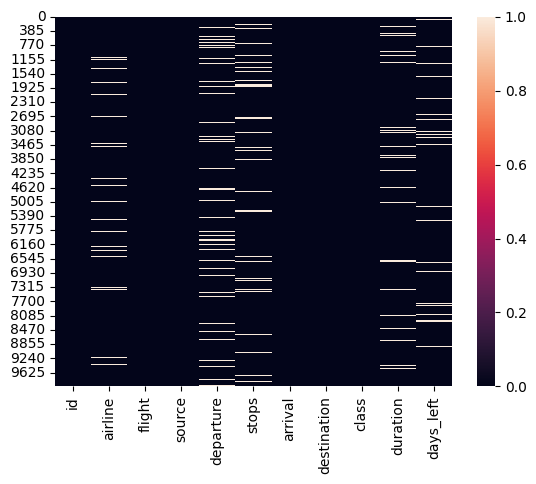

In [7]:
sns.heatmap(test_data.isna())

# RUBRICS1 - Identify data types of different columns

In [8]:
print(train_data.columns)
print(test_data.columns)

Index(['id', 'airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class', 'duration', 'days_left', 'price'],
      dtype='object')
Index(['id', 'airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class', 'duration', 'days_left'],
      dtype='object')


In [9]:
train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10000 non-null  int64  
 1   ai

# RUBRICS 2 - descriptive statistics of numerical columns

In [9]:
print(train_data.describe())
print(test_data.describe())

                id      duration     days_left         price
count  40000.00000  36987.000000  35562.000000   40000.00000
mean   19999.50000     12.004088     26.197936   20801.49025
std    11547.14972      7.108063     13.469232   22729.14842
min        0.00000      0.830000      1.000000    1105.00000
25%     9999.75000      6.670000     15.000000    4687.00000
50%    19999.50000     11.080000     26.000000    7353.00000
75%    29999.25000     15.920000     38.000000   42521.00000
max    39999.00000     47.080000     49.000000  114704.00000
                id     duration    days_left
count  10000.00000  9418.000000  9304.000000
mean    4999.50000    12.005125    26.163156
std     2886.89568     7.086652    13.453717
min        0.00000     0.920000     1.000000
25%     2499.75000     6.670000    15.000000
50%     4999.50000    11.170000    26.000000
75%     7499.25000    15.920000    38.000000
max     9999.00000    40.420000    49.000000


# RUBRICS 3 - Identify and handle the missing values

In [10]:
print(train_data.isnull().sum())
print()
print(test_data.isnull().sum())

id                0
airline        4613
flight            0
source            0
departure      4792
stops          2319
arrival           0
destination       0
class             0
duration       3013
days_left      4438
price             0
dtype: int64

id               0
airline        548
flight           0
source           0
departure      920
stops          651
arrival          0
destination      0
class            0
duration       582
days_left      696
dtype: int64


# HANDLING MISSING VALUES FOR CATEGORICAL COLUMNS

In [11]:
from sklearn.impute import SimpleImputer, KNNImputer
categorical_cols=train_data.select_dtypes(include=['object']).columns
categorical_cols

Index(['airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class'],
      dtype='object')

In [14]:
train_data['airline'].mode()[0]

'Vistara'

In [12]:
imputer=SimpleImputer(strategy='most_frequent')
train_data[categorical_cols]=imputer.fit_transform(train_data[categorical_cols])
test_data[categorical_cols]=imputer.fit_transform(test_data[categorical_cols])
train_data[categorical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   airline      40000 non-null  object
 1   flight       40000 non-null  object
 2   source       40000 non-null  object
 3   departure    40000 non-null  object
 4   stops        40000 non-null  object
 5   arrival      40000 non-null  object
 6   destination  40000 non-null  object
 7   class        40000 non-null  object
dtypes: object(8)
memory usage: 2.4+ MB


# HANDLING MISSING VALUES FOR NUMBERICAL COLUMNS

In [15]:
numerical_cols=train_data.select_dtypes(include=['float64']).columns
numerical_cols

Index(['duration', 'days_left'], dtype='object')

In [16]:
knn_imputer=KNNImputer(n_neighbors=5)
train_data[numerical_cols]=knn_imputer.fit_transform(train_data[numerical_cols])
test_data[numerical_cols]=knn_imputer.fit_transform(test_data[numerical_cols])

In [17]:
combined_num_cols=pd.concat((train_data[numerical_cols],test_data[numerical_cols]),axis=1)
combined_num_cols.corr()

,duration,days_left,duration,days_left
duration,1.000000,-0.033319,0.002989,0.012687
days_left,-0.033319,1.000000,-0.010319,0.000286
duration,0.002989,-0.010319,1.000000,-0.030176
days_left,0.012687,0.000286,-0.030176,1.000000


In [18]:
train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      40000 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    40000 non-null  object 
 5   stops        40000 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     40000 non-null  float64
 10  days_left    40000 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10000 non-null  int64  
 1   ai

# RUBRICS 4 - Identify and handle duplicates

In [19]:
print("Number of duplicate rows in train_data:", train_data.duplicated().sum())
print("Number of duplicate rows in test_data:", test_data.duplicated().sum())

Number of duplicate rows in train_data: 0
Number of duplicate rows in test_data: 0


# RUBRICS 5 - Identify and handle outliers

In [20]:
num_cols = train_data.select_dtypes(include=np.number).columns

def count_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

print("Outlier counts per numerical column:")
for col in num_cols:
    count = count_outliers_iqr(train_data, col)
    if count > 0:
        print(f"{col}: {count} outliers")

Outlier counts per numerical column:
duration: 323 outliers
price: 14 outliers


# RUBRICS 6 - Present at least three visualizations and provide insights for the same

<Figure size 1500x800 with 0 Axes>

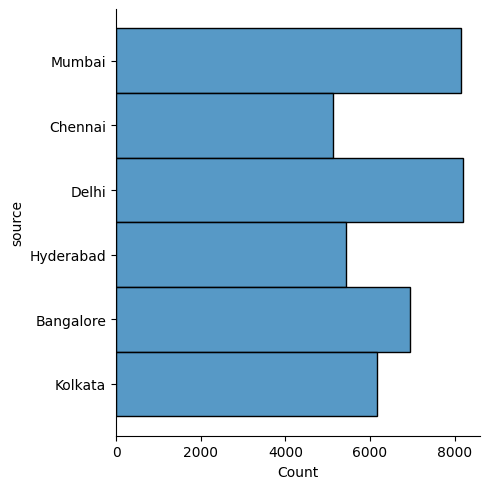

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))
sns.displot(y='source',data=train_data)
plt.show()

<Axes: xlabel='class', ylabel='count'>

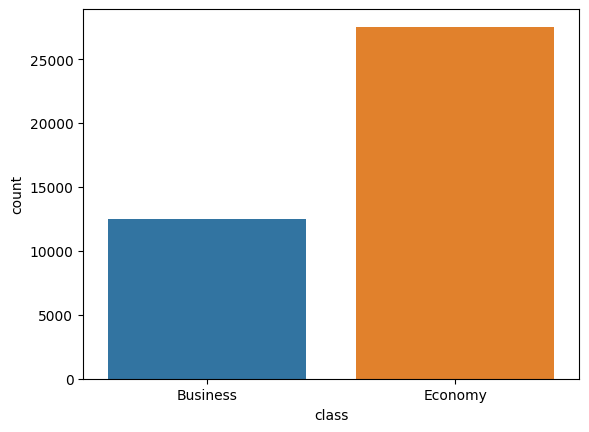

In [18]:
sns.countplot(x='class',data=train_data)

In [ ]:
sns.countplot(x='class',data=test_data)

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


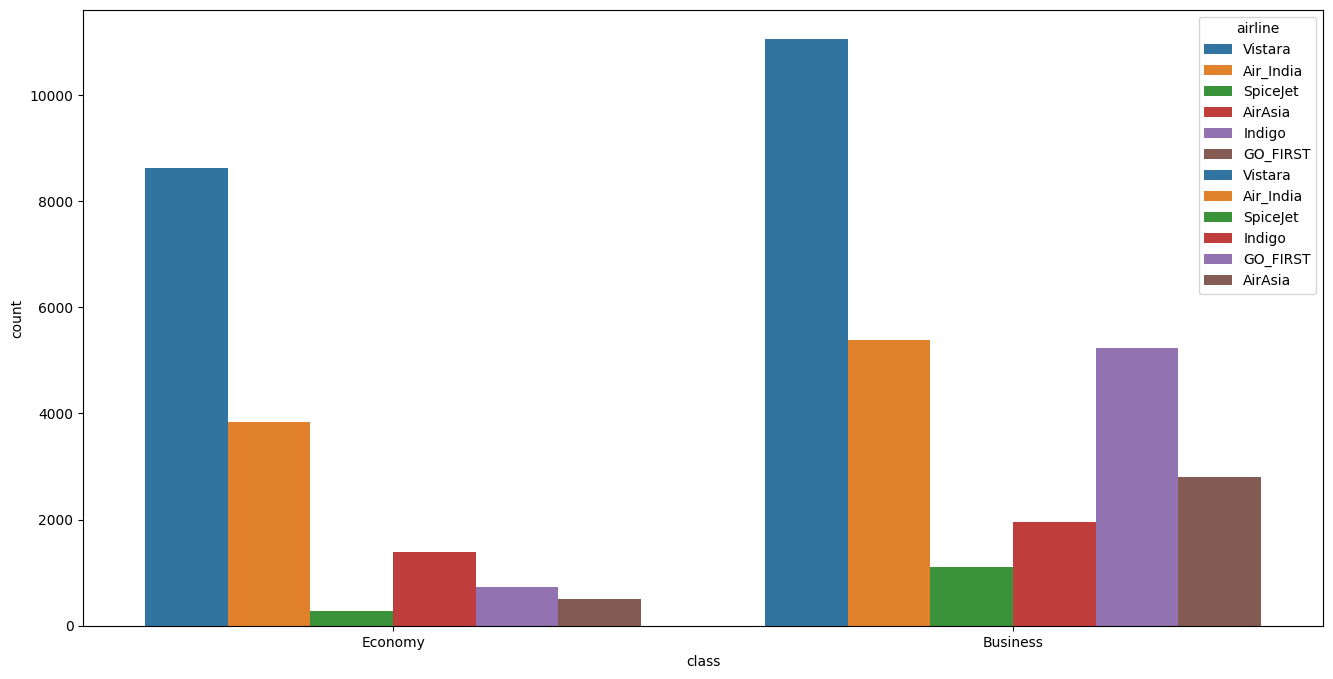

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
print(sns.countplot(x='class',data=train_data,hue='airline'))
print(sns.countplot(x='class',data=test_data,hue='airline'))

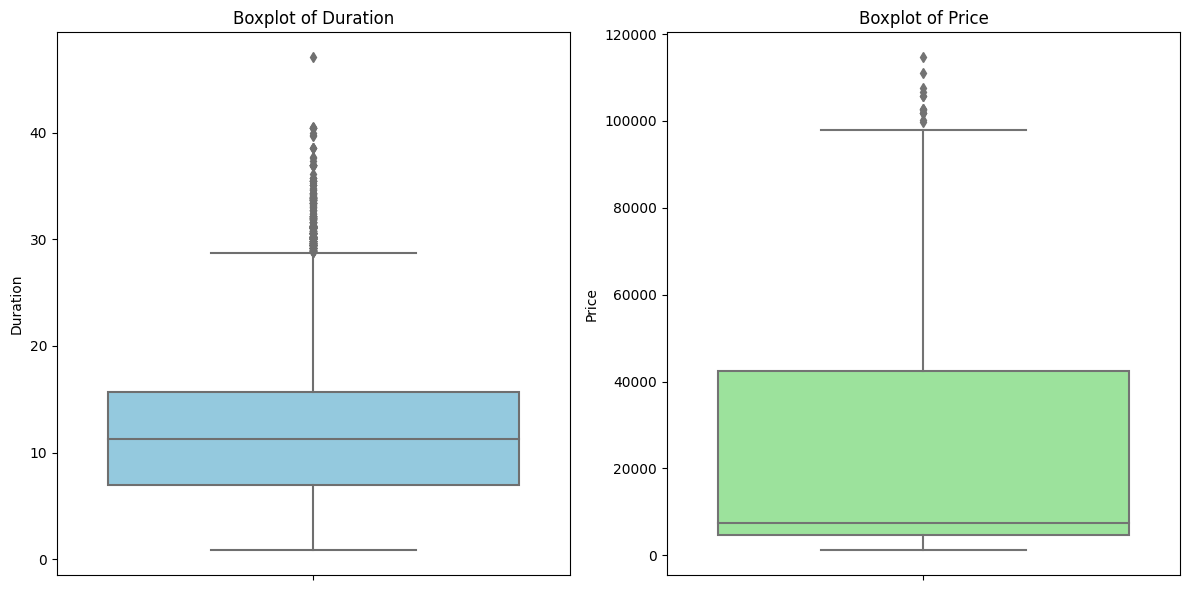

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# First subplot: Duration
plt.subplot(1, 2, 1)
sns.boxplot(y=train_data['duration'], color='skyblue')
plt.title('Boxplot of Duration')
plt.ylabel('Duration')

# Second subplot: Price
plt.subplot(1, 2, 2)
sns.boxplot(y=train_data['price'], color='lightgreen')
plt.title('Boxplot of Price')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

In [ ]:
print(train_data['airline'].unique())
print(train_data['airline'].value_counts())

# Visualized - each airline with total counts

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

airline_counts = train_data['airline'].value_counts()

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

sns.barplot(x=airline_counts.index, y=airline_counts.values, palette="viridis")

plt.xlabel('Airline')
plt.ylabel('Number of Records')
plt.title('Count of Records per Airline')
plt.show()

# HISTOGRAM CHART WITH PRICE  RANGE AND FREQUENCY

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(train_data['price'], bins=10, edgecolor='black')
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(train_data['price'], bins=30, kde=True, color='darkgreen',edgecolor='black')
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.50)
plt.show()

In [ ]:
train_data.hist(column='price',by='class')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#PRICE VS DURATION
train_data.plot.scatter(x='price',y='duration',c='green')
plt.show()

In [ ]:
# RUBRICS 6 - Scale Numerical features and Encode Categorical features

In [ ]:
train_data.head()
test_data.head()

In [21]:
train_data_scale=train_data.drop(columns=['id','flight','price'],axis=1)
test_data_scale=test_data.drop(columns=['id','flight'],axis=1)
train_data_scale.head()

,airline,source,departure,stops,arrival,destination,class,duration,days_left
0,Vistara,Mumbai,Early_Morning,one,Night,Chennai,Business,13.152,40.0
1,Air_India,Chennai,Evening,one,Morning,Mumbai,Economy,16.080,26.0
2,SpiceJet,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.920,25.0
3,Vistara,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.500,22.0
4,Air_India,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.830,20.0


In [22]:
train_data_scale['duration'].mean()

11.99202298424717

In [24]:
train_data_scale['airline'].value_counts()

airline
Vistara      19676
Air_India     9222
Indigo        5236
GO_FIRST      2805
AirAsia       1958
SpiceJet      1103
Name: count, dtype: int64

In [25]:
train_data_scale['airline']=train_data_scale['airline'].replace({'Vistara':6, 'Air_India':1, 'SpiceJet':2, 'AirAsia':3, 'Indigo':4, 'GO_FIRST':5})
train_data_scale['source']=train_data_scale['source'].replace({'Mumbai':6, 'Chennai':1, 'Delhi':2, 'Hyderabad':3, 'Bangalore':4, 'Kolkata':5})
train_data_scale['departure']=train_data_scale['departure'].replace({'Early_Morning':6, 'Evening':1, 'Morning':2, 'Afternoon':3, 'Night':4, 'Late_Night':5})
train_data_scale['stops']=train_data_scale['stops'].replace({'one':1, 'zero':0, 'two_or_more':2})
train_data_scale['arrival']=train_data_scale['arrival'].replace({'Early_Morning':6, 'Evening':1, 'Morning':2, 'Afternoon':3, 'Night':4, 'Late_Night':5})
train_data_scale['destination']=train_data_scale['destination'].replace({'Mumbai':6, 'Chennai':1, 'Delhi':2, 'Hyderabad':3, 'Bangalore':4, 'Kolkata':5})
train_data_scale['class']=train_data_scale['class'].replace({'Business':1, 'Economy':2})
print(train_data_scale.head())

   airline  source  departure  stops  arrival  destination  class  duration  \
0        6       6          6      1        4            1      1    13.152   
1        1       1          1      1        2            6      2    16.080   
2        2       2          6      0        2            1      2     2.920   
3        6       3          6      0        2            4      2     1.500   
4        1       1          6      1        2            4      2     4.830   

   days_left  
0       40.0  
1       26.0  
2       25.0  
3       22.0  
4       20.0  


In [26]:
test_data_scale['airline']=test_data_scale['airline'].replace({'Vistara':6, 'Air_India':1, 'SpiceJet':2, 'AirAsia':3, 'Indigo':4, 'GO_FIRST':5})
test_data_scale['source']=test_data_scale['source'].replace({'Mumbai':6, 'Chennai':1, 'Delhi':2, 'Hyderabad':3, 'Bangalore':4, 'Kolkata':5})
test_data_scale['departure']=test_data_scale['departure'].replace({'Early_Morning':6, 'Evening':1, 'Morning':2, 'Afternoon':3, 'Night':4, 'Late_Night':5})
test_data_scale['stops']=test_data_scale['stops'].replace({'one':1, 'zero':0, 'two_or_more':2})
test_data_scale['arrival']=test_data_scale['arrival'].replace({'Early_Morning':6, 'Evening':1, 'Morning':2, 'Afternoon':3, 'Night':4, 'Late_Night':5})
test_data_scale['destination']=test_data_scale['destination'].replace({'Mumbai':6, 'Chennai':1, 'Delhi':2, 'Hyderabad':3, 'Bangalore':4, 'Kolkata':5})
test_data_scale['class']=test_data_scale['class'].replace({'Business':1, 'Economy':2})
print(test_data_scale.head())

   airline  source  departure  stops  arrival  destination  class  duration  \
0        6       4          2      0        3            2      2     2.670   
1        1       1          6      0        2            2      2    17.418   
2        2       2          1      1        1            4      2    11.182   
3        6       1          4      1        1            5      1    21.000   
4        1       2          2      1        1            6      1     7.250   

   days_left  
0       18.0  
1        5.0  
2       44.0  
3       26.0  
4       22.0  


In [27]:
y=train_data['price']
y.head()

0    64173
1     4357
2     3251
3     1776
4     3584
Name: price, dtype: int64

<Axes: >

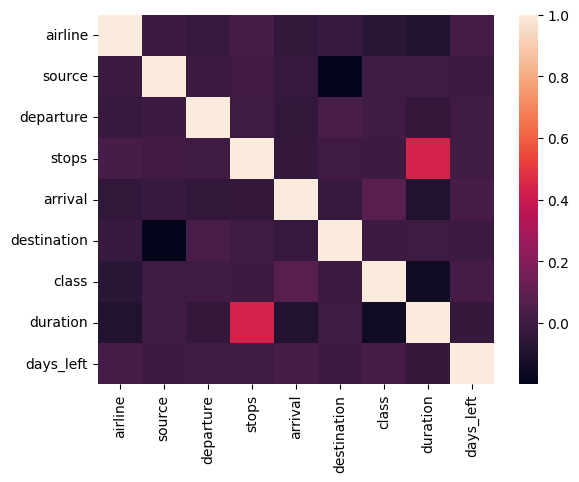

In [25]:
import seaborn as sns
sns.heatmap(train_data_scale.corr())

In [ ]:
sns.heatmap(test_data_scale.corr())

In [ ]:
train_data[numerical_cols].head()

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#Fit and transform on training data
scaler.fit_transform(train_data_scale)
scaler.transform(test_data_scale)

array([[ 0.84939078,  0.21480066, -0.588859  , ...,  0.67278809,
        -1.35465832, -0.63998859],
       [-1.58882999, -1.53498411,  1.71756547, ...,  0.67278809,
         0.78849247, -1.65265985],
       [-1.10118584, -0.95172252, -1.16546511, ...,  0.67278809,
        -0.11771097,  1.38535392],
       ...,
       [ 0.84939078, -1.53498411, -0.588859  , ..., -1.48635212,
        -0.26477285, -0.17260186],
       [-1.58882999, -0.36846093, -1.16546511, ..., -1.48635212,
         0.67979456,  1.77484287],
       [ 0.84939078, -0.36846093,  1.71756547, ..., -1.48635212,
         0.72774952, -1.49686428]])

In [ ]:
train_data_scale[:5]

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train_data_scale, y, test_size=0.33, random_state=42)

In [30]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(26800, 9)
(13200, 9)
(26800,)
(13200,)


# RUBRICS 8 - Model Building (at least 7) 

In [31]:
#1 LINEAR REGRESSION
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)
y_pred=lin_reg.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)
print("MAE:",mae)

MSE: 49177196.77141382
RMSE: 7012.645490213648
R2: 0.905238278822478
MAE: 4599.289740250981


In [32]:
from sklearn.preprocessing import PolynomialFeatures
#train_data['airline_duration'] = train_data['airline'] * train_data['duration']
#test_data['airline_duration'] = test_data['airline'] * test_data['duration']

poly = PolynomialFeatures(degree=2) # Add polynomial features up to degree 2
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_train_poly, y_train)
y_pred_poly = lin_reg_poly.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
print("\nLinear Regression with Polynomial Features (degree 2):")
print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("R2:", r2_poly)
print("MAE:", mae_poly)


Linear Regression with Polynomial Features (degree 2):
MSE: 32906837.263656575
RMSE: 5736.44814006512
R2: 0.9365903560524752
MAE: 3548.0883102771436


In [33]:
#CROSS VALIDATION
from sklearn.model_selection import cross_validate
lin_cv=cross_validate(lin_reg,X_train,y_train,cv=5,return_train_score=True, scoring='neg_mean_absolute_error')
lin_cv['train_score']
lin_test_score=-np.mean(lin_cv['test_score'])
lin_test_score

4603.8000751206955

In [34]:
#2 RIDGE REGRESSION
from sklearn.linear_model import Ridge
ridge_reg=Ridge()
ridge_reg.fit(X_train,y_train)
y_pred=ridge_reg.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)
print("MAE:",mae)

MSE: 49177027.001173854
RMSE: 7012.633385624395
R2: 0.9052386059602816
MAE: 4599.450157954686


In [ ]:
#Cross validation
ridge_cv=cross_validate(ridge_reg,X_train,y_train,cv=5,return_train_score=True, scoring='neg_mean_absolute_error')
ridge_cv['train_score']
ridge_test_score=-np.mean(ridge_cv['test_score'])
ridge_test_score

In [35]:
#3 LASSO REGRESSION
from sklearn.linear_model import Lasso
lass_reg=Lasso()
lass_reg.fit(X_train,y_train)
y_pred=lass_reg.predict(X_test)
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)
print("MAE:",mae)

MSE: 49177359.685411505
RMSE: 7012.657105934348
R2: 0.9052379648962715
MAE: 4598.816493998488


In [ ]:
lasso_cv=cross_validate(lass_reg,X_train,y_train,cv=5,return_train_score=True, scoring='neg_mean_absolute_error')
lasso_cv['train_score']
lasso_test_score=-np.mean(lasso_cv['test_score'])
lasso_test_score

In [36]:
#4 DECISION TREE
from sklearn.tree import DecisionTreeRegressor
dt_reg=DecisionTreeRegressor()
dt_reg.fit(X_train,y_train)
y_pred=dt_reg.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)
print("MAE:",mae)

MSE: 29788767.671075337
RMSE: 5457.90872689122
R2: 0.9425987026184195
MAE: 2613.9805176767672


In [ ]:
#Cross validation
dt_cv=cross_validate(dt_reg,X_train,y_train,cv=5,return_train_score=True, scoring='neg_mean_absolute_error')
dt_cv['train_score']
dt_test_score=-np.mean(dt_cv['test_score'])
dt_test_score

# BEST MODEL, R2 score got 97% before hypertuning

In [37]:
5#RANDOM FOREST REGRESSION -default 
from sklearn.ensemble import RandomForestRegressor
rf_reg=RandomForestRegressor(n_estimators=100)
rf_reg.fit(X_train,y_train)
y_pred=rf_reg.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)
print("MAE:",mae)

MSE: 16413330.211033497
RMSE: 4051.3368424550304
R2: 0.9683724261819522
MAE: 2220.002078292339


In [ ]:
#Cross validation
rf_cv=cross_validate(rf_reg,X_train,y_train,cv=5,return_train_score=True, scoring='neg_mean_absolute_error')
rf_cv['train_score']
rf_test_score=-np.mean(rf_cv['test_score'])
rf_test_score

In [39]:
#5 ENSEMBLE -RANDOM FOREST REGRESSION
#creating 20 decision trees
thirty_decision_trees=[DecisionTreeRegressor(random_state=42,max_depth=i,max_leaf_nodes=i) for i in range(2,32)]
thirty_decision_trees

[DecisionTreeRegressor(max_depth=2, max_leaf_nodes=2, random_state=42),
 DecisionTreeRegressor(max_depth=3, max_leaf_nodes=3, random_state=42),
 DecisionTreeRegressor(max_depth=4, max_leaf_nodes=4, random_state=42),
 DecisionTreeRegressor(max_depth=5, max_leaf_nodes=5, random_state=42),
 DecisionTreeRegressor(max_depth=6, max_leaf_nodes=6, random_state=42),
 DecisionTreeRegressor(max_depth=7, max_leaf_nodes=7, random_state=42),
 DecisionTreeRegressor(max_depth=8, max_leaf_nodes=8, random_state=42),
 DecisionTreeRegressor(max_depth=9, max_leaf_nodes=9, random_state=42),
 DecisionTreeRegressor(max_depth=10, max_leaf_nodes=10, random_state=42),
 DecisionTreeRegressor(max_depth=11, max_leaf_nodes=11, random_state=42),
 DecisionTreeRegressor(max_depth=12, max_leaf_nodes=12, random_state=42),
 DecisionTreeRegressor(max_depth=13, max_leaf_nodes=13, random_state=42),
 DecisionTreeRegressor(max_depth=14, max_leaf_nodes=14, random_state=42),
 DecisionTreeRegressor(max_depth=15, max_leaf_nodes=15

In [40]:
for model in thirty_decision_trees:
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  mse=mean_squared_error(y_test,y_pred)
  rmse=np.sqrt(mse)
  r2=r2_score(y_test,y_pred)
  mae=mean_absolute_error(y_test,y_pred)
  print("MSE:",mse)
  print("RMSE:",rmse)
  print("R2:",r2)
  print("MAE:",mae)

MSE: 62058422.07186797
RMSE: 7877.716805767263
R2: 0.8804168745846498
MAE: 4870.3465230581805
MSE: 44158197.35595091
RMSE: 6645.163455924234
R2: 0.914909611359161
MAE: 4301.47201268073
MSE: 40629711.711748876
RMSE: 6374.14399835373
R2: 0.9217088068145052
MAE: 4188.961261336407
MSE: 37385241.610519916
RMSE: 6114.347194142635
R2: 0.9279607201256801
MAE: 3820.87390320961
MSE: 36298123.540345095
RMSE: 6024.792406410788
R2: 0.9300555361423757
MAE: 3791.4087972967823
MSE: 34974025.167453855
RMSE: 5913.884101625078
R2: 0.9326070000130546
MAE: 3729.5009932814946
MSE: 33494676.0546184
RMSE: 5787.4585142891865
R2: 0.9354576234189869
MAE: 3702.4835604501723
MSE: 33040378.451378766
RMSE: 5748.0760652046665
R2: 0.9363330296160891
MAE: 3684.457599359848
MSE: 32784396.80262539
RMSE: 5725.766045048068
R2: 0.9368262920063486
MAE: 3678.728703263509
MSE: 32697036.63261149
RMSE: 5718.13226784861
R2: 0.9369946301918568
MAE: 3670.9169707968854
MSE: 32400978.968024764
RMSE: 5692.185781228926
R2: 0.9375651168

In [41]:
#6 ENSEMBLE - VOTING REGRESSION
from sklearn.ensemble import VotingRegressor
vote_reg=VotingRegressor(estimators=[(f" model{i}",model) for i, model in enumerate(thirty_decision_trees)])
vote_reg.fit(X_train,y_train)
vote_y_pred=vote_reg.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)
print("MAE:",mae)


MSE: 28274611.963424418
RMSE: 5317.387701063786
R2: 0.9455163963953689
MAE: 3306.2196271425623


In [43]:
7#SUPPORT VECTOR MACHINE - REGRESSION SVR
from sklearn.svm import SVR
svr_reg=SVR()
svr_reg.fit(X_train,y_train)
y_pred=svr_reg.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)
print("MAE:",mae)

MSE: 697755504.819728
RMSE: 26415.062082450764
R2: -0.3445360235791919
MAE: 15937.176467313982


In [ ]:
#cross_validation
#svr_cv=cross_validate(svr_reg,X_train,y_train,cv=5,return_train_score=True, scoring='neg_mean_absolute_error')
#svr_test_score=-np.mean(svr_cv['test_score'])
#svr_test_score

In [ ]:
#8 KNN for Regression
from sklearn.neighbors import KNeighborsRegressor
knn_reg=KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train,y_train)
y_pred=knn_reg.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)
print("MAE:",mae)

In [ ]:
#cross_validation
knn_cv=cross_validate(knn_reg,X_train,y_train,cv=5,return_train_score=True, scoring='neg_mean_absolute_error')
knn_test_score=-np.mean(knn_cv['test_score'])
knn_test_score

In [ ]:
#9 MULTI LAYER PERCEPTRON - MLP REGRESSOR
from sklearn.neural_network import MLPRegressor
mlp_reg=MLPRegressor(hidden_layer_sizes=(5,),activation='relu',random_state=42,max_iter=200)
knn_reg.fit(X_train,y_train)
y_pred=knn_reg.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)
print("MAE:",mae)

In [ ]:
#cross_validation
mlp_cv=cross_validate(mlp_reg,X_train,y_train,cv=5,return_train_score=True, scoring='neg_mean_absolute_error')
mlp_test_score=-np.mean(mlp_cv['test_score'])
mlp_test_score

# RUBRICS 9 - HYPERPARAMETER TUNING WITH 3 MODELS

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [44]:
#HYPER PARAMETER TUNING FOR RIDGE
from sklearn.model_selection import GridSearchCV

# Define a range of alpha values to test
param_grid = {'alpha': [0.1, 1, 10, 100]}

# Create a GridSearchCV object
grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the grid search to your data
grid_search.fit(X_train, y_train)

# Get the best alpha value
best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha for Ridge regression: {best_alpha}")

# Train a Ridge regression model with the best alpha
best_ridge_reg = Ridge(alpha=best_alpha)
best_ridge_reg.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred_optimized = best_ridge_reg.predict(X_test)
mse_optimized = mean_squared_error(y_test, y_pred_optimized)
rmse_optimized = np.sqrt(mse_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)

print("\nOptimized Ridge Regression Results:")
print("MSE:", mse_optimized)
print("RMSE:", rmse_optimized)
print("R2:", r2_optimized)
print("MAE:", mae_optimized)

Best alpha for Ridge regression: 0.1

Optimized Ridge Regression Results:
MSE: 49177178.4673458
RMSE: 7012.644185137714
R2: 0.9052383140933983
MAE: 4599.305754773458


In [ ]:
#HYPER PARAMETER TUNING FOR DT Regressor
import numpy as np
# 5 DECISION TREE REGRESSOR - Hyperparameter Tuning
# Define the parameter grid for Decision Tree Regressor
param_grid_dt = {
    'max_depth': [None, 5, 10, 15, 20],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],   # Minimum number of samples required to be at a leaf node
    'splitter': ['best', 'random']   # Strategy to choose the split at each node
}

# Create a GridSearchCV object for Decision Tree Regressor
grid_search_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_dt, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to your data
grid_search_dt.fit(X_train, y_train)

# Get the best parameters and the best estimator
best_dt_params = grid_search_dt.best_params_
best_dt_reg = grid_search_dt.best_estimator_

print("\nBest parameters for Decision Tree Regressor (after GridSearchCV):", best_dt_params)

# Make predictions with the best Decision Tree model
y_pred_best_dt = best_dt_reg.predict(X_test)

# Evaluate the best Decision Tree model
mse_best_dt = mean_squared_error(y_test, y_pred_best_dt)
rmse_best_dt = np.sqrt(mse_best_dt)
r2_best_dt = r2_score(y_test, y_pred_best_dt)
mae_best_dt = mean_absolute_error(y_test, y_pred_best_dt)

print("\nOptimized Decision Tree Regressor Results (after GridSearchCV):")
print("MSE:", mse_best_dt)
print("RMSE:", rmse_best_dt)
print("R2:", r2_best_dt)
print("MAE:", mae_best_dt)

In [ ]:
import numpy as np
# Hyperparameter tuning for Random Forest Regressor using GridSearchCV

# Define the parameter grid for Random Forest Regressor
param_grid_rf = {
  'n_estimators': [30, 80, 100], # Number of trees in the forest
  'max_depth': [None, 10, 20, 30],   # Maximum depth of the tree
  'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
  'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Create a GridSearchCV object for Random Forest Regressor
# Use 'neg_mean_squared_error' for scoring, which is minimized
grid_search_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to your training data
print("Starting GridSearchCV for Random Forest Regressor...")
grid_search_rf.fit(X_train, y_train)
print("GridSearchCV for Random Forest Regressor completed.")

# Get the best parameters and the best estimator
best_rf_params = grid_search_rf.best_params_
best_rf_reg = grid_search_rf.best_estimator_

print("\nBest parameters for Random Forest Regressor (after GridSearchCV):", best_rf_params)

# Make predictions with the best Random Forest model
y_pred_best_rf = best_rf_reg.predict(X_test)

# Evaluate the best Random Forest model
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)

print("\nOptimized Random Forest Regressor Results (after GridSearchCV):")
print("MSE:", mse_best_rf)
print("RMSE:", rmse_best_rf)
print("R2:", r2_best_rf)
print("MAE:", mae_best_rf)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distributions for RandomizedSearchCV
param_distributions_rf = {
  'n_estimators': [100, 200, 300, 400, 500],
  'max_depth': [None, 10, 20, 30, 40, 50],
  'min_samples_split': [2, 5, 10, 15, 20],
  'min_samples_leaf': [1, 2, 4, 8]
}

random_search_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_distributions=param_distributions_rf,
                                      n_iter=50, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)

# Fit the random search to your training data
print("\nStarting RandomizedSearchCV for Random Forest Regressor...")
random_search_rf.fit(X_train, y_train)
print("RandomizedSearchCV for Random Forest Regressor completed.")

# Get the best parameters and the best estimator from random search
best_rf_params_rand = random_search_rf.best_params_
best_rf_reg_rand = random_search_rf.best_estimator_

print("\nBest parameters for Random Forest Regressor (after RandomizedSearchCV):", best_rf_params_rand)

# Make predictions with the best Random Forest model from random search
y_pred_best_rf_rand = best_rf_reg_rand.predict(X_test)

# Evaluate the best Random Forest model from random search
mse_best_rf_rand = mean_squared_error(y_test, y_pred_best_rf_rand)
rmse_best_rf_rand = np.sqrt(mse_best_rf_rand)
r2_best_rf_rand = r2_score(y_test, y_pred_best_rf_rand)
mae_best_rf_rand = mean_absolute_error(y_test, y_pred_best_rf_rand)

print("\nOptimized Random Forest Regressor Results (after RandomizedSearchCV):")
print("MSE:", mse_best_rf_rand)
print("RMSE:", rmse_best_rf_rand)
print("R2:", r2_best_rf_rand)
print("MAE:", mae_best_rf_rand)

In [ ]:
param_grid_svr = {
    'C': [0.1, 1, 10, 100],          
    'epsilon': [0.01, 0.1, 0.2],    
    'kernel': ['rbf', 'linear'],    
    'gamma': ['scale', 'auto']      
                                 }

grid_search_svr = GridSearchCV(SVR(), param_grid_svr, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to your training data
print("\nStarting GridSearchCV for SVR...")
grid_search_svr.fit(X_train, y_train)
print("GridSearchCV for SVR completed.")

# Get the best parameters and the best estimator
best_svr_params = grid_search_svr.best_params_
best_svr_reg = grid_search_svr.best_estimator_

print("\nBest parameters for SVR (after GridSearchCV):", best_svr_params)

# Make predictions with the best SVR model
y_pred_best_svr = best_svr_reg.predict(X_test)

# Evaluate the best SVR model
mse_best_svr = mean_squared_error(y_test, y_pred_best_svr)
rmse_best_svr = np.sqrt(mse_best_svr)
r2_best_svr = r2_score(y_test, y_pred_best_svr)
mae_best_svr = mean_absolute_error(y_test, y_pred_best_svr)

print("\nOptimized SVR Results (after GridSearchCV):")
print("MSE:", mse_best_svr)
print("RMSE:", rmse_best_svr)
print("R2:", r2_best_svr)
print("MAE:", mae_best_svr)

In [ ]:
param_distributions_svr_rand = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'epsilon': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5],
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1] 
}

random_search_svr = RandomizedSearchCV(SVR(), param_distributions=param_distributions_svr_rand,
                                       n_iter=50, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)

# Fit the random search to your training data
print("\nStarting RandomizedSearchCV for SVR...")
random_search_svr.fit(X_train, y_train)
print("RandomizedSearchCV for SVR completed.")

# Get the best parameters and the best estimator from random search
best_svr_params_rand = random_search_svr.best_params_
best_svr_reg_rand = random_search_svr.best_estimator_

print("\nBest parameters for SVR (after RandomizedSearchCV):", best_svr_params_rand)

# Make predictions with the best SVR model from random search
y_pred_best_svr_rand = best_svr_reg_rand.predict(X_test)

# Evaluate the best SVR model from random search
mse_best_svr_rand = mean_squared_error(y_test, y_pred_best_svr_rand)
rmse_best_svr_rand = np.sqrt(mse_best_svr_rand)
r2_best_svr_rand = r2_score(y_test, y_pred_best_svr_rand)
mae_best_svr_rand = mean_absolute_error(y_test, y_pred_best_svr_rand)

print("\nOptimized SVR Results (after RandomizedSearchCV):")
print("MSE:", mse_best_svr_rand)
print("RMSE:", rmse_best_svr_rand)
print("R2:", r2_best_svr_rand)
print("MAE:", mae_best_svr_rand)

# RUBRICS 10 - MODELS PERFORMANCE COMPARISONS

In [ ]:
best_model=RandomForestRegressor(n_estimators=140)
best_model.fit(train_data_scale,y)
test_pred=best_model.predict(test_data_scale)
test_pred=np.clip(test_pred, 0, None)

In [ ]:
submission = pd.DataFrame({
    "id": range(test_data_scale.shape[0]),
    "price": test_pred
})
submission.to_csv("submission.csv", index=False)
submission